# 2026 Biomedical Hackathon

Here is the code for the hackathon

In [27]:
!pip install --upgrade --no-cache-dir scipy scanpy anndata


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [13]:
# For Mac to hide output do Cmd+Shift+H
#!pip install "numpy<2" 
#!pip install scipy==1.11.4 
#!pip install  scanpy==1.12.3
!pip install matplotlib==3.11.1
!pip install squidpy



[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip

[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: pip install --upgrade pip


In [49]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scanpy as sc
import squidpy as sq 
import anndata as ad
import seaborn as sns 

#np.random.seed(265)

In [3]:

counts_train = pd.read_csv('counts_train.csv', index_col=0)
counts_test  = pd.read_csv('counts_test.csv',  index_col=0)
meta_train   = pd.read_csv('meta_train.csv',   index_col=0)
meta_test    = pd.read_csv('meta_test.csv',    index_col=0)
for df in (counts_train, counts_test, meta_train, meta_test):
    df.index = df.index.astype(str)
    df.index.name = 'Cell_ID'

print('counts_train:', counts_train.shape)
print('counts_test :', counts_test.shape)
print('meta_train  :', meta_train.shape)
print('meta_test   :', meta_test.shape)

counts_train: (5000, 200)
counts_test : (5000, 200)
meta_train  : (5000, 12)
meta_test   : (5000, 12)


In [5]:
print('train label NA fraction:', meta_train['MERFISH_cell_type_annotation'].isna().mean())
print('test  label NA fraction:', meta_test['MERFISH_cell_type_annotation'].isna().mean())

meta_test[['volume', 'center_x', 'center_y', 'MERFISH_cell_type_annotation',
           'Region', 'Excitatory_vs_Inhibitory']].head()

train label NA fraction: 0.0
test  label NA fraction: 1.0


,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory
Cell_ID,,,,,,
2796212800954100068,3647.375000,9979.925856,8091.551222,NaN,1.0,excitatory
2707604000123100074,1100.773071,5385.479527,9654.331573,NaN,NaN,NaN
2796212800080100088,3029.895508,7193.083494,550.081350,NaN,NaN,NaN
2946331700000000970,3262.542236,8948.681067,309.374372,NaN,NaN,NaN
2796212800882100299,1551.463623,7788.225136,7682.970213,NaN,1.0,inhibitory


/usr/local/lib/python3.12/functools.py:912: ImplicitModificationWarning: Transforming to str index.
  return dispatch(args[0].__class__)(*args, **kw)
/tmp/ipykernel_419/2410336775.py:40: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(counts_train, resolution=0.5)


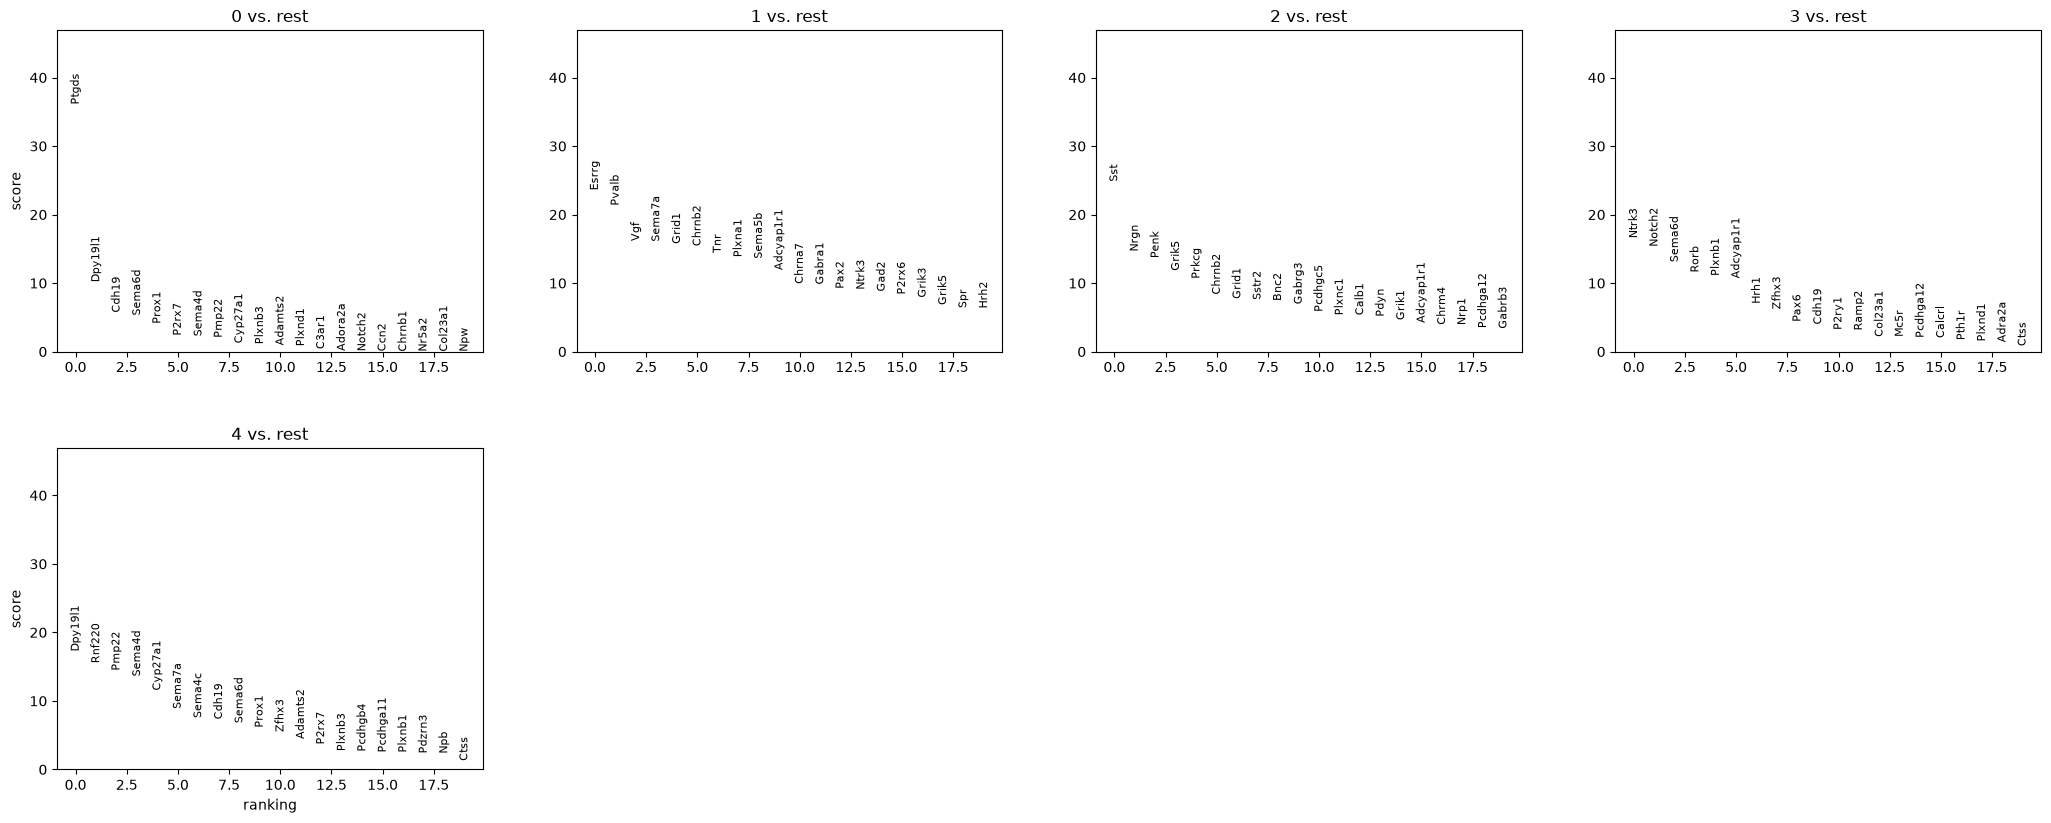

In [61]:
"SCANPY PREPROCESSING AND PRELIMINARY MODEL"

#import scanpy as sc
import pandas as pd
import numpy as np


counts_train  = sc.read_csv('counts_test.csv') # read in count training with scanpy
meta_train   = pd.read_csv('meta_train.csv') # read in meta training with pandas

counts_train.obs = meta_train # attatch meta data to an object that contains count data

# 1) compute QC matrices

counts_train.obs['total_counts'] = counts_train.X.sum(axis=1) # total counts= sum of all transcripts detected in cells
counts_train.obs['n_genes'] = (counts_train.X > 0).sum(axis=1) # number of genes with atleast one transcript

# 2) filter low quality cells (remove debris, failed cells, and noise)

sc.pp.filter_cells(counts_train, min_counts=20) # remove cells that don't have enough RNA transcripts to be real
sc.pp.filter_cells(counts_train, min_genes=3) # remove cells that express almost nothing
#sc.pp = scanpy.preprocessing module

# 3) normalize data (standard log1p normalization)

sc.pp.normalize_total(counts_train, target_sum=1e4)
sc.pp.log1p(counts_train)

# 4) run PCA (principle component analysis compresses the data)
sc.pp.pca(counts_train)

# 5) build neighbor graph (needed for the cell clustering algorithm)

sc.pp.neighbors(counts_train, n_neighbors=20, n_pcs=30)

# 6) cluster the cells

# sc.tl.leiden() runs the Leiden clsutering algorithm
# this groups by optimizes modulatrity on nearest k-neighbor from heighbor graph
sc.tl.leiden(counts_train, resolution=0.5)
counts_train.obs['leiden']

# 7) identify marker genes

# sc.tl.rank_gene_groups() compares leiden clusters against each other
# genes that are highly expressed against other genes become our marker genes
sc.tl.rank_genes_groups(counts_train, 'leiden', method='wilcoxon')

# visualize the marker genes

sc.pl.rank_genes_groups(counts_train, n_genes=20)

# [0-4] vs rest represents cluster 0/1/2/3/4 vs rest of the clusters
# y axis is the ranking score from the differential expression test (wilxocen) FOR THAT CLUSTER
# the x axis is gene index in the ranking list across the clusters; doesn't mean anything other than index


In [9]:
counts_test_grid = counts_test.astype(np.int32)
print(counts_test_grid)

                     Pmfbp1  Sema7a  Bdnf  Cck  Sema3a  Sema3g  Adcyap1r1  \
Cell_ID                                                                     
2796212800954100068       0       1     0    0       0       0          1   
2707604000123100074       0       0     0    1       0       0          0   
2796212800080100088       0       0     0    0       0       0          1   
2946331700000000970       0       2     0    0       0       0          0   
2796212800882100299       0       0     0    0       0       0          1   
...                     ...     ...   ...  ...     ...     ...        ...   
2787889600409100230       0       1     0    0       0       0          0   
2795584800388100027       0       0     0    0       0       0          0   
2656143800130100146       0       0     0    0       0       0          0   
2707604700272100140       0       1     0    0       0       0          0   
2787445900694100124       0       0     0    0       0       0          0   

In [39]:
# This cell focuses on using the AnnData package to see the 
# gene expression information

adata = sc.AnnData(counts_test_grid.T)

adata.obs_names = counts_test_grid.columns
adata.var_names = counts_test_grid.index

print(adata)
print(adata.obs_names[:5])
print(adata.var_names[:5])

#adata.obs = meta_test

AnnData object with n_obs × n_vars = 200 × 5000
    layers: None (.X)
Index(['Pmfbp1', 'Sema7a', 'Bdnf', 'Cck', 'Sema3a'], dtype='str')
Index(['2796212800954100068', '2707604000123100074', '2796212800080100088',
       '2946331700000000970', '2796212800882100299'],
      dtype='str', name='Cell_ID')


'#filter the cells \nsc.pp.filter_cells(counts_train, min_counts=20) \n\n\n\n\n# this is for a 3D spatial data representation \nsc.pl.embedding(adata_train, basis="spatial3d", projection="3d", color="Cell_class")\n\n#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly \nsq.gr.spatial_neighbors(adata, coord_type="generic", spatial_key="spatial3d")\nsq.gr.nhood_enrichment(adata, cluster_key="Cell_class")\nsq.pl.nhood_enrichment(\n    adata, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100\n)\n\n# spatial variability of gene expression \n# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression\n#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.\n\n\n'

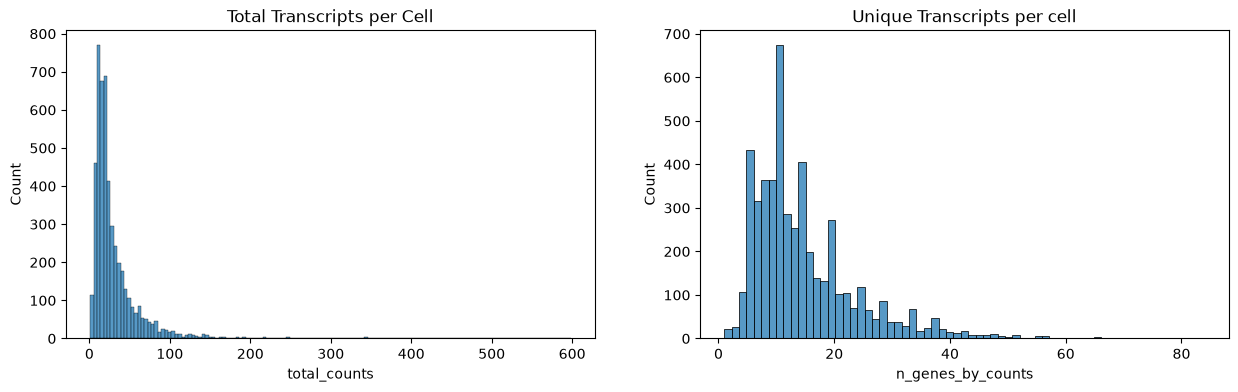

In [47]:
'''Squidpy Processing '''


adata_train = sq.read.vizgen(path = "." ,counts_file = 'counts_test.csv', meta_file = 'meta_train.csv') # reads files from 

sc.pp.calculate_qc_metrics(adata_train, percent_top= None, inplace=True, log1p=True)

fig, (axs1,axs2) = plt.subplots(1,2, figsize=(15,4))
axs1.set_title("Total Transcripts per Cell")
sns.histplot(adata_train.obs["total_counts"],kde = False, ax = axs1)

axs2.set_title("Unique Transcripts per cell")
sns.histplot(adata_train.obs["n_genes_by_counts"],kde = False, ax = axs2)







/tmp/ipykernel_419/278472319.py:12: FutureWarning: The `igraph` implementation of leiden clustering is *orders of magnitude faster*. Set the flavor argument to (and install if needed) 'igraph' to use it.
In the future, the default backend for leiden will be igraph instead of leidenalg. To achieve the future defaults please pass: `flavor='igraph'` and `n_iterations=2`. `directed` must also be `False` to work with igraph’s implementation.
  sc.tl.leiden(adata_train,resolution = 0.5) # cluster the cells into subgroups


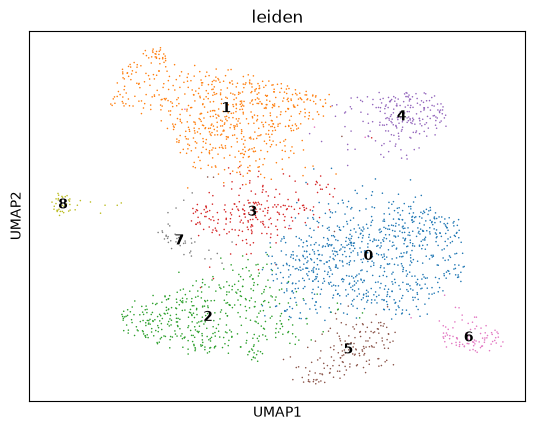

'# this is for a 3D spatial data representation \nsc.pl.embedding(adata_train, basis="spatial3d", projection="3d", color="Cell_class")\n\n#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly \nsq.gr.spatial_neighbors(adata_train, coord_type="generic", spatial_key="spatial3d")\nsq.gr.nhood_enrichment(adata_train, cluster_key="Cell_class")\nsq.pl.nhood_enrichment(\n    adata_train, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100\n)\n\n# spatial variability of gene expression \n# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression\n#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.\n\n'

In [65]:
# fixing up the data 

#filter the cells 
sc.pp.filter_cells(adata_train, min_counts=20) 
# can also use min_genes=200

sc.pp.normalize_total(adata_train,inplace = True) # normalize counts per cell 
sc.pp.log1p(adata_train) # log
sc.pp.pca(adata_train) #pca analysis 
sc.pp.neighbors(adata_train) # computer neighborhood graph 
sc.tl.umap(adata_train) #embed the neighborhood graph of the data 
sc.tl.leiden(adata_train,resolution = 0.5) # cluster the cells into subgroups 

sc.pl.umap(adata_train,color= "leiden",legend_loc='on data',size = 5,wspace = 0.4)

'''# this is for a 3D spatial data representation 
sc.pl.embedding(adata_train, basis="spatial3d", projection="3d", color="Cell_class")

#neighborhood enrichment analysis: do certain cell types sit next to each other more than randomly 
sq.gr.spatial_neighbors(adata_train, coord_type="generic", spatial_key="spatial3d")
sq.gr.nhood_enrichment(adata_train, cluster_key="Cell_class")
sq.pl.nhood_enrichment(
    adata_train, cluster_key="Cell_class", method="single", cmap="inferno", vmin=-50, vmax=100
)

# spatial variability of gene expression 
# Uses these statistic methods:  Moran’s I and Geary’s C -> provide a score on the degree of spatial variability of gene expression
#statistic as well as the p-value are computed for each gene, and false discrovert rate correction is performed.

'''

In [53]:
meta_test

,Datasets,volume,center_x,center_y,MERFISH_cell_type_annotation,Region,Excitatory_vs_Inhibitory,Segment,Gender,Mouse_ID,AP_position,Section_ID
Cell_ID,,,,,,,,,,,,
2796212800954100068,20240613,3647.375000,9979.925856,8091.551222,NaN,1.0,excitatory,2.0,female,F4,1,0613_F4_C
2707604000123100074,20240415,1100.773071,5385.479527,9654.331573,NaN,NaN,NaN,NaN,male,M3,4,0415_M3_T
2796212800080100088,20240613,3029.895508,7193.083494,550.081350,NaN,NaN,NaN,NaN,female,F5,3,0613_F5_S
2946331700000000970,20240415,3262.542236,8948.681067,309.374372,NaN,NaN,NaN,NaN,female,F2,1,0415_F2_C
2796212800882100299,20240613,1551.463623,7788.225136,7682.970213,NaN,1.0,inhibitory,7.0,female,F3,1,0613_F3_C
...,...,...,...,...,...,...,...,...,...,...,...,...
2787889600409100230,20240503,1029.303711,6057.870768,9031.221613,NaN,NaN,NaN,NaN,male,M4,2,0503_M4_L
2795584800388100027,20240610,2450.753418,8097.346720,6582.207908,NaN,NaN,NaN,NaN,female,F4,3,0610_F4_S
2656143800130100146,20240328,2418.427979,2592.243209,3928.415030,NaN,NaN,NaN,NaN,male,M3,1,0328_M3_C


<a style='text-decoration:none;line-height:16px;display:flex;color:#5B5B62;padding:10px;justify-content:end;' href='https://deepnote.com?utm_source=created-in-deepnote-cell&projectId=455d92ce-61c0-4f15-b27b-1ef3d91a99f7' target="_blank">

Created in <span style='font-weight:600;margin-left:4px;'>Deepnote</span></a>